In [1]:
import sys 
import os

In [2]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [43]:
import pandas as pd
import yaml
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [4]:
yaml_path = rf"..\config\config.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [5]:
yaml_path = rf"..\config\model.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config_model = yaml.safe_load(f)

# Params

# Read Train / val dataset

In [6]:
pipeline_name="Pipeline1"

In [7]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')  

X_val = pd.read_parquet(fr'..\data\feature_eng\X_val_feat_eng_{pipeline_name}.parquet')
y_val = pd.read_parquet(fr'..\data\feature_eng\y_val_feat_eng_{pipeline_name}.parquet')

In [8]:
model_name = "RandomForestRegressor_pipeline1"

In [9]:
model_path = rf'..\models\single_model\pkl\{model_name}.pkl'
with open(model_path, "rb") as file:
        model = pickle.load(file)

# Drop columns

In [10]:
X_train.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)

X_val.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)


In [11]:
params = model.get_params()['randomforestregressor'].get_params()

In [12]:
params

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'max_depth': 12,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 345,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 23,
 'verbose': 0,
 'warm_start': False}

In [13]:
test_params = params.copy()

# max_depth

In [14]:
params['max_depth']

12

In [15]:
scores_max_depth_train = []
scores_max_depth_val = []
for n in range(1, 25):
    test_params['max_depth'] = n
    clf_rf_max_depth = RandomForestRegressor(**test_params)
    clf_rf_max_depth.fit(X_train, y_train.values.ravel())
    y_pred_train = clf_rf_max_depth.predict(X_train)
    y_pred_val = clf_rf_max_depth.predict(X_val)
    scores_max_depth_train.append(mean_squared_error(y_train, y_pred_train))
    scores_max_depth_val.append(mean_squared_error(y_val, y_pred_val))

val_max_depth = pd.Series(scores_max_depth_val, index=range(1, 25), name='Validation')
train_max_depth = pd.Series(scores_max_depth_train, index=range(1, 25), name='Training')

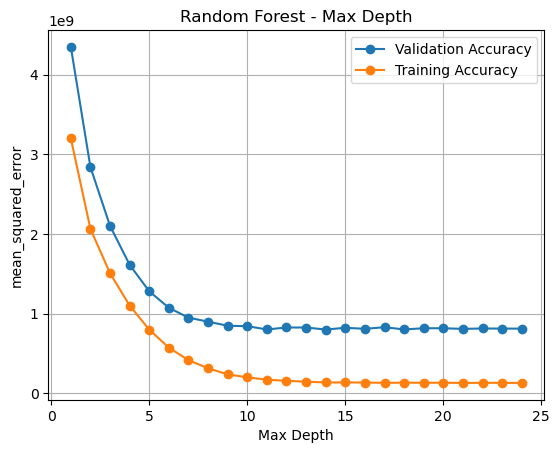

In [16]:
(pd.DataFrame(
    {'Validation Accuracy': val_max_depth, 
     'Training Accuracy': train_max_depth})
.plot(
    marker='o', 
    title='Random Forest - Max Depth', 
    xlabel='Max Depth', 
    ylabel='mean_squared_error'))
plt.grid()

# Max_Features

In [17]:
max_features = ['sqrt', 'log2', None, 0.5, 0.75, 1.0]

In [18]:
scores_max_features_train = []
scores_max_features_val = []


for n in max_features:
    test_params['max_features'] = n
    clf_rf_max_features = RandomForestRegressor(**test_params)
    clf_rf_max_features.fit(X_train, y_train.values.ravel())
    y_pred_train = clf_rf_max_features.predict(X_train)
    y_pred_val = clf_rf_max_features.predict(X_val)
    scores_max_features_train.append(mean_squared_error(y_train, y_pred_train))
    scores_max_features_val.append(mean_squared_error(y_val, y_pred_val))

val_max_features = pd.Series(scores_max_features_val, index=max_features, name='Validation')
train_max_features = pd.Series(scores_max_features_train, index=max_features, name='Training')

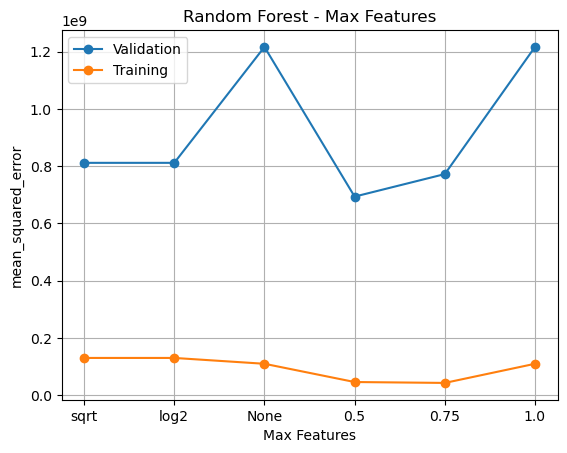

In [19]:
(pd.DataFrame(
    {'Validation': val_max_features, 
     'Training': train_max_features})
.plot(
    marker='o', 
    title='Random Forest - Max Features', 
    xlabel='Max Features', 
    ylabel='mean_squared_error'))
plt.grid()

# max_leaf_nodes

In [20]:
max_leaf_nodes = [i for i in range(2, 30)]
max_leaf_nodes.insert(0, None)

In [21]:
scores_max_leaf_nodes_train = []
scores_max_leaf_nodes_val = []


for n in max_leaf_nodes:
    test_params['max_leaf_nodes'] = n
    clf_rf_max_leaf_nodes = RandomForestRegressor(**test_params)
    clf_rf_max_leaf_nodes.fit(X_train, y_train.values.ravel())
    y_pred_train = clf_rf_max_leaf_nodes.predict(X_train)
    y_pred_val = clf_rf_max_leaf_nodes.predict(X_val)
    scores_max_leaf_nodes_train.append(mean_squared_error(y_train, y_pred_train))
    scores_max_leaf_nodes_val.append(mean_squared_error(y_val, y_pred_val))

val_max_leaf_nodes = pd.Series(scores_max_leaf_nodes_val, index=max_leaf_nodes, name='Validation')
train_max_leaf_nodes = pd.Series(scores_max_leaf_nodes_train, index=max_leaf_nodes, name='Training')

In [22]:
(pd.DataFrame(
    {'Validation': val_max_leaf_nodes, 
     'Training': train_max_leaf_nodes}))

,Validation,Training
NaN,1.216246e+09,1.099007e+08
2.0,4.248325e+09,3.242179e+09
3.0,3.262794e+09,2.572964e+09
4.0,2.573637e+09,2.255130e+09
5.0,2.356680e+09,2.004971e+09
6.0,2.253780e+09,1.883730e+09
7.0,2.139263e+09,1.766489e+09
8.0,2.040754e+09,1.680065e+09
9.0,1.818991e+09,1.598288e+09
10.0,1.589685e+09,1.477870e+09


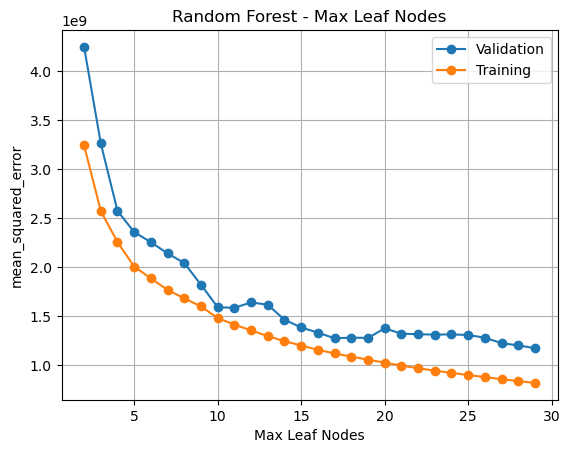

In [23]:
(pd.DataFrame(
    {'Validation': val_max_leaf_nodes, 
     'Training': train_max_leaf_nodes})
.plot(
    marker='o', 
    title='Random Forest - Max Leaf Nodes', 
    xlabel='Max Leaf Nodes', 
    ylabel='mean_squared_error'))
plt.grid()

# min_samples_leaf

In [24]:
min_samples_leaf = [i for i in range(2, 20)]

In [25]:
scores_min_samples_leaf_train = []
scores_min_samples_leaf_val = []


for n in min_samples_leaf:
    test_params['min_samples_leaf'] = n
    clf_rf_min_samples_leaf = RandomForestRegressor(**test_params)
    clf_rf_min_samples_leaf.fit(X_train, y_train.values.ravel())
    y_pred_train = clf_rf_min_samples_leaf.predict(X_train)
    y_pred_val = clf_rf_min_samples_leaf.predict(X_val)
    scores_min_samples_leaf_train.append(mean_squared_error(y_train, y_pred_train))
    scores_min_samples_leaf_val.append(mean_squared_error(y_val, y_pred_val))

val_min_samples_leaf = pd.Series(scores_min_samples_leaf_val, index=min_samples_leaf, name='Validation')
train_min_samples_leaf = pd.Series(scores_min_samples_leaf_train, index=min_samples_leaf, name='Training')

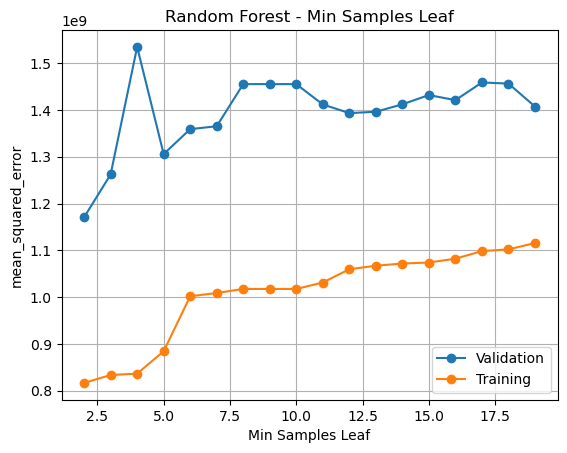

In [26]:
(pd.DataFrame(
    {'Validation': val_min_samples_leaf, 
     'Training': train_min_samples_leaf})
.plot(
    marker='o', 
    title='Random Forest - Min Samples Leaf', 
    xlabel='Min Samples Leaf', 
    ylabel='mean_squared_error'))
plt.grid()

# min_samples_split

In [27]:
min_samples_split = [i for i in range(2, 20)]

In [28]:
scores_min_samples_split_train = []
scores_min_samples_split_val = []


for n in min_samples_split:
    test_params['min_samples_split'] = n
    clf_rf_min_samples_split = RandomForestRegressor(**test_params)
    clf_rf_min_samples_split.fit(X_train, y_train.values.ravel())
    y_pred_train = clf_rf_min_samples_split.predict(X_train)
    y_pred_val = clf_rf_min_samples_split.predict(X_val)
    scores_min_samples_split_train.append(mean_squared_error(y_train, y_pred_train))
    scores_min_samples_split_val.append(mean_squared_error(y_val, y_pred_val))

val_min_samples_split = pd.Series(scores_min_samples_split_val, index=min_samples_split, name='Validation')
train_min_samples_split = pd.Series(scores_min_samples_split_train, index=min_samples_split, name='Training')

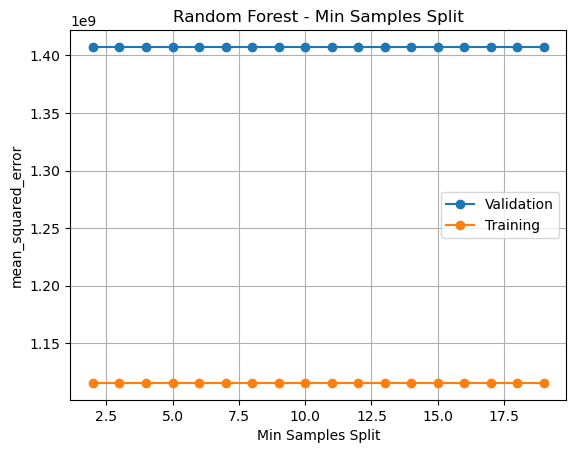

In [29]:
(pd.DataFrame(
    {'Validation': val_min_samples_split, 
     'Training': train_min_samples_split})
.plot(
    marker='o', 
    title='Random Forest - Min Samples Split', 
    xlabel='Min Samples Split', 
    ylabel='mean_squared_error'))
plt.grid()

# n_estimators

In [30]:
n_estimators = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]

In [31]:
scores_n_estimators_train = []
scores_n_estimators_val = []


for n in n_estimators:
    test_params['n_estimators'] = n
    clf_rf_n_estimators = RandomForestRegressor(**test_params)
    clf_rf_n_estimators.fit(X_train, y_train.values.ravel())
    y_pred_train = clf_rf_n_estimators.predict(X_train)
    y_pred_val = clf_rf_n_estimators.predict(X_val)
    scores_n_estimators_train.append(mean_squared_error(y_train, y_pred_train))
    scores_n_estimators_val.append(mean_squared_error(y_val, y_pred_val))

val_n_estimators = pd.Series(scores_n_estimators_val, index=n_estimators, name='Validation')
train_n_estimators = pd.Series(scores_n_estimators_train, index=n_estimators, name='Training')

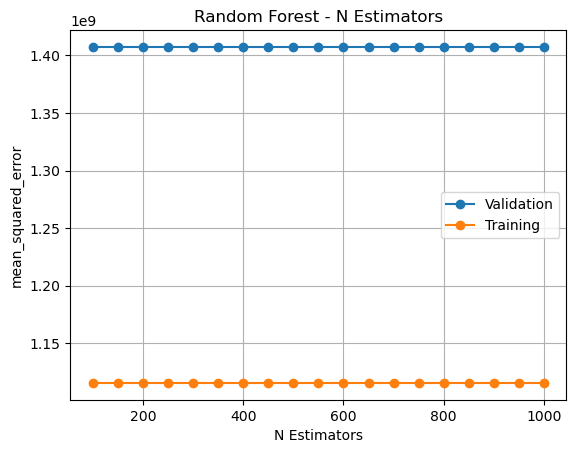

In [32]:
(pd.DataFrame(
    {'Validation': val_n_estimators, 
     'Training': train_n_estimators})
.plot(
    marker='o', 
    title='Random Forest - N Estimators', 
    xlabel='N Estimators', 
    ylabel='mean_squared_error'))
plt.grid()

# Final Model

## Params

In [33]:
params

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'max_depth': 12,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 345,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 23,
 'verbose': 0,
 'warm_start': False}

In [63]:
params['max_depth'] = 6
params['max_leaf_nodes'] = 12
params['min_samples_leaf'] = 6

In [64]:
clf_rf_final_model = RandomForestRegressor(**params)
clf_rf_final_model.fit(X_train, y_train.values.ravel())
y_pred_train = clf_rf_final_model.predict(X_train)
y_pred_val = clf_rf_final_model.predict(X_val)
scores_final_model_train = [mean_squared_error(y_train, y_pred_train)]
scores_final_model_val = [mean_squared_error(y_val, y_pred_val)]

mape_final_model_train = [mean_absolute_percentage_error(y_train, y_pred_train)]
mape_final_model_val = [mean_absolute_percentage_error(y_val, y_pred_val)]



In [65]:
scores_final_model_train[0], scores_final_model_val[0]

(1200977059.8973844, 1693436648.4174232)

In [66]:
mape_final_model_train[0], mape_final_model_val[0]

(0.14696761144540219, 0.1686098003091115)

In [67]:
params

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'max_depth': 6,
 'max_features': 'log2',
 'max_leaf_nodes': 12,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 6,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 345,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 23,
 'verbose': 0,
 'warm_start': False}